# Plan: 16S rRNA Phylogenetic Tree — Cyanobacteria vs. Chloroplast Origin

## Context & Goal

I have 6 contigs from metagenomic assemblies (4 from Mammoth Cave, KY interior; 2 from Columbia Lake, MN) each containing a 16S rRNA locus with 93.6–97.5% identity to cyanobacterial references. BLASTp of flanking proteins shows several contigs have chloroplast-encoded gene hits (PsbC, ATP synthase CF0, LAGLIDADG endonucleases) from green algae (Chlorophyta), raising the question of whether these 16S sequences are from free-living cyanobacteria or chloroplast genomes.

**Goal:** Build a publication-quality 16S rRNA phylogenetic tree that includes:
1. My 6 novel 16S sequences
2. Representative type strains from all major cyanobacterial orders
3. A set of chloroplast 16S sequences spanning algal and plant lineages
4. An appropriate outgroup

The tree should allow me to determine whether each novel sequence clusters with free-living cyanobacteria or within a chloroplast clade.

---

## Step 1: Assemble the query + anchor 16S sequences

### 1a. The 6 novel contigs (query sequences)

Extract 16S rRNA from each contig. These are the sequences whose cyanobacterium-vs-chloroplast identity the tree will resolve.

| Sample Site | Contig | 16S Identity | GC% (contig) | Provisional call |
|---|---|---|---|---|
| Mammoth Cave, KY (interior) | contig_225 | 93.6% | 33.6% | Likely chloroplast |
| Mammoth Cave, KY (interior) | contig_227 | 93.6% | 35.2% | Likely chloroplast |
| Mammoth Cave, KY (interior) | contig_531 | 97.0% | 34.2% | Uncertain — no chloroplast gene hits |
| Mammoth Cave, KY (interior) | contig_427 | 96.6% | 27.9% | Putative chloroplast |
| Columbia Lake, MN | contig_1504 | 95.3% | 29.5% | Putative chloroplast |
| Columbia Lake, MN | contig_3677 | 97.5% | 30.2% | Likely chloroplast |

Use barrnap or coordinate-based extraction on the racon2 polished assemblies to pull the 16S sequences. Save to `novel_6_16S.fasta`.

### 1b. Confirmed cyanobacteria from notebook 02 (anchor sequences)

Notebook 02's community tree already contains SILVA-confirmed cyanobacterial 16S sequences from the full 10-sample dataset. Pull these from the existing combined FASTA:

```
results/10_tax_profile/all_samples_cyano_16S_outgroup.fna
```

These sequences have known SILVA taxonomy and will serve as anchor points that pin the cyanobacterial clades in the tree, making it easier to interpret where the 6 novel contigs land. Exclude the outgroup entry (Gloeobacter kilaueensis) — the new tree will use Gloeobacter violaceus PCC 7421 instead (see Step 2c). Rename each tip to include sample site and SILVA taxon for readability.

The sequences included are:

| Sample | Contig | SILVA identification |
|---|---|---|
| KY-Mam-100624-C | contig_225 | Novel (one of the 6 above — will be included via 1a) |
| MN-Por-091024-A | contig_24 | Cyanobium / Synechococcales |
| MN-Por-091024-A | contig_1022 | Calothrix / Nostocales |
| MN-Por-091024-A | contig_282 | Phormidiaceae incertae sedis |
| TN-Cla-092324-E | contig_35 | Limnothrix / Limnotrichaceae |
| GA-Cor-092624-B | contig_112 | Limnothrix / Limnotrichaceae |
| MN-Col-091924-B | contig_1504 | Novel (one of the 6 above — will be included via 1a) |
| MN-Col-091924-B | contig_3535 | Synechococcus elongatus-like |
| FL-Hom-052325-G | contig_134 | Nodosilinea / Nodosilineales |

**I will provide the 16S sequences or the full contig FASTA files.** If I provide full contigs, use barrnap or a coordinate-based extraction to pull the 16S genes.

---

## Step 2: Download reference 16S sequences

### 2a. Cyanobacterial orders (Strunecký et al. 2023 classification)

Download 1–2 type strain 16S sequences per order from NCBI. Use the type strain of the type species for each order when possible. The current orders per the 2023 Strunecký et al. reclassification (J. Phycol. 59:12–51) are:

1. **Gloeobacterales** — e.g., *Gloeobacter violaceus* PCC 7421 (use as OUTGROUP)
2. **Gloeomargaritales** — e.g., *Gloeomargarita lithophora*
3. **Acaryochloridales** (syn. Thermosynechococcales) — e.g., *Acaryochloris marina*
4. **Synechococcales** — e.g., *Synechococcus elongatus* PCC 7942, *Prochlorococcus marinus*
5. **Prochlorothrichales** — e.g., *Prochlorothrix hollandica*
6. **Pseudanabaenales** — e.g., *Pseudanabaena catenata*
7. **Leptolyngbyales** — e.g., *Leptolyngbya boryana*
8. **Nodosilineales** — e.g., *Nodosilinea nodulosa* UTEX 2910
9. **Oculatellales** — e.g., *Oculatella subterranea*
10. **Aegeococcales** — e.g., *Aegeococcus anagnostidisi* (if 16S available)
11. **Geitlerinematales** — e.g., *Geitlerinema splendidum*
12. **Desertifilales** — e.g., *Desertifilum tharense*
13. **Oscillatoriales** — e.g., *Oscillatoria princeps*, *Planktothrix agardhii*
14. **Coleofasciculales** — e.g., *Coleofasciculus chthonoplastes*
15. **Spirulinales** — e.g., *Spirulina major*
16. **Gomontiellales** — e.g., *Crinalium epipsammum*
17. **Chroococcales** — e.g., *Microcystis aeruginosa*, *Cyanobacterium aponinum*
18. **Chroococcidiopsidales** — e.g., *Chroococcidiopsis thermalis*
19. **Pleurocapsales** — e.g., *Pleurocapsa minor*
20. **Nostocales** — e.g., *Nostoc punctiforme*, *Anabaena cylindrica*

For any order where the type strain 16S is not in GenBank, use the most closely related well-characterized strain.

**How to download:** Use Entrez Direct (EDirect) or Biopython to query NCBI nucleotide for each strain's 16S rRNA gene. Search with the organism name + "16S ribosomal RNA" and filter for sequences 1200–1600 bp. Save all to a file called `cyano_references_16S.fasta`.

### 2b. Chloroplast 16S sequences

This is critical for my question. Download chloroplast 16S rRNA sequences from organisms that appeared in my BLAST hits, plus broad representation:

**Green algae (Chlorophyta) — priority, since these appeared in my BLAST hits:**
- *Chlamydomonas reinhardtii* (chloroplast genome)
- *Chlamydomonas chlamydogama* (if available; appeared in my BLAST)
- *Chlorella vulgaris* (appeared in my BLAST)
- *Desmodesmus abundans* (appeared in my BLAST)
- *Bracteacoccus giganteus* (appeared in my BLAST)
- *Coelastrella saipanensis* (appeared in my BLAST)
- *Bathycoccus prasinos* (appeared in my BLAST — prasinophyte)

**Other algal chloroplasts for breadth:**
- *Euglena gracilis* (Euglenophyta)
- *Cyanophora paradoxa* (Glaucophyta — this is the most "cyanobacteria-like" plastid)
- A rhodophyte, e.g., *Porphyra purpurea* or *Cyanidioschyzon merolae*
- A diatom, e.g., *Thalassiosira pseudonana* (Stramenopiles/secondary endosymbiosis)

**Land plant chloroplasts:**
- *Arabidopsis thaliana*
- *Oryza sativa* (rice)
- *Hordeum vulgare* (barley — close to *Hordeum erectifolium* from my BLAST hit)
- *Rhynchospora pubera* (sedge — appeared in my BLAST)
- *Marchantia polymorpha* (liverwort — basal land plant)

**How to download:** For organisms with full chloroplast genomes in GenBank, extract the 16S rRNA (rrn16) gene from the chloroplast genome annotation. These are typically listed as "rrn16" or "16S ribosomal RNA" in the chloroplast genome features. Save to `chloroplast_references_16S.fasta`.

### 2c. Outgroup

Use *Gloeobacter violaceus* PCC 7421 as the outgroup. It sits at the base of all cyanobacteria (it's the only cyanobacterium without thylakoids) and is well-established as a root for cyanobacterial 16S trees.

---

## Step 3: Combine and align

```bash
# Combine all sequences into one file
cat novel_16S.fasta cyano_references_16S.fasta chloroplast_references_16S.fasta > all_16S_combined.fasta

# Align with MAFFT (use L-INS-i for accuracy with <200 sequences)
mafft --localpair --maxiterate 1000 all_16S_combined.fasta > all_16S_aligned.fasta
```

Install MAFFT if needed: `conda install -c bioconda mafft` or `sudo apt install mafft`

---

## Step 4: Trim the alignment

Trim poorly aligned regions. Use trimAl:

```bash
trimal -in all_16S_aligned.fasta -out all_16S_trimmed.fasta -automated1
```

Or use Gblocks. The `-automated1` flag in trimAl uses a heuristic to choose the best trimming parameters. After trimming, the alignment should be ~1200–1400 positions.

Install: `conda install -c bioconda trimal`

---

## Step 5: Build the phylogenetic tree

### Option A: Maximum Likelihood with IQ-TREE (recommended)

```bash
# IQ-TREE with automatic model selection and 1000 ultrafast bootstraps
iqtree2 -s all_16S_trimmed.fasta -m MFP -bb 1000 -alrt 1000 -nt AUTO
```

- `-m MFP`: ModelFinder Plus — tests all substitution models and picks the best one by BIC
- `-bb 1000`: 1000 ultrafast bootstrap replicates
- `-alrt 1000`: SH-aLRT test (a second branch support metric)
- `-nt AUTO`: use all available cores

The output tree will be in `all_16S_trimmed.fasta.treefile` (Newick format).

Install: `conda install -c bioconda iqtree`

### Option B: Bayesian with MrBayes (if you want posterior probabilities)

This is slower but gives Bayesian posterior probabilities, which some reviewers prefer. Convert alignment to NEXUS format first, then run MrBayes with GTR+I+G model for ~1–5 million generations.

---

## Step 6: Visualize and annotate the tree

Use Python with `toytree`, `ete3`, or `Bio.Phylo` to plot. Alternatively, use iTOL (Interactive Tree Of Life, https://itol.embl.de/) for publication figures — you can upload the Newick tree and add color annotations.

**Color scheme to match your existing gene map figure:**
- Green: Cyanobacterial orders (free-living)
- Purple: Chloroplast/eukaryotic plastid clades
- Yellow: Your novel 16S sequences (to stand out)
- Gray: Outgroup (Gloeobacter)

**Labeling:** Each tip should show: `Organism name (Order/Lineage) [Accession]`
Your novel sequences: `contig_XXX (Site, % identity)`

---

## Step 7: Interpret the tree

What to look for:
- **If your novel 16S sequences nest WITHIN a chloroplast clade** (i.e., sister to Chlorophyta, Streptophyta, or other plastid 16S): → chloroplast origin confirmed
- **If your novel 16S sequences nest WITHIN a free-living cyanobacterial order** (e.g., within or sister to Synechococcales, Nostocales, etc.): → genuine novel cyanobacterium
- **If they fall on a long branch between clades**: → highly divergent lineage, possibly novel at order level (exciting but interpret cautiously)

**Expectation based on current evidence:**
- contigs 225, 227, 427, 1504, 3677 will likely cluster with Chlorophyta chloroplast 16S sequences
- contig_531 (97.0% identity, from dark cave zone, no chloroplast gene hits) is the strongest candidate for a free-living cyanobacterium — pay special attention to where this one lands

---

## Dependencies summary

```bash
conda create -n phylo_16S python=3.11
conda activate phylo_16S
conda install -c bioconda mafft trimal iqtree barrnap
pip install biopython toytree matplotlib
```

---

## Notes

- The Strunecký et al. 2023 classification (J. Phycol. 59:12–51) split the old polyphyletic Synechococcales and Oscillatoriales into multiple new monophyletic orders. Using this updated taxonomy for your reference set will give better resolution.
- 16S alone has limited phylogenetic informativeness above genus level in cyanobacteria (as noted by Strunecký et al. 2023). If placement is ambiguous, consider a multilocus or phylogenomic approach later.
- For the chloroplast 16S sequences, make sure you're extracting from the plastid genome, not the nuclear 18S. The GenBank annotation will say "chloroplast" in the source features.

In [1]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
from pathlib import Path
import subprocess, re, time, sys
from Bio import SeqIO, Entrez
import pandas as pd

# Bootstrap: find project root to load shared utilities
_p = Path.cwd().resolve()
for _parent in [_p] + list(_p.parents):
    if (_parent / 'Snakefile').exists():
        sys.path.insert(0, str(_parent / 'notebooks'))
        break
from utils import find_project_root, load_config

PROJECT   = find_project_root()
cfg       = load_config()
POLISH    = PROJECT / 'results' / '04_polish'
TAX_DIR   = PROJECT / 'results' / '10_tax_profile'
OUT_DIR   = PROJECT / 'results' / '14_phylo_16S'
OUT_DIR.mkdir(exist_ok=True)

Entrez.email = cfg.get('entrez_email', 'palmer.lab@wisc.edu')

NOVEL_CONTIGS = {
    'KY-Mam-100624-C': ['contig_225', 'contig_227', 'contig_531', 'contig_427'],
    'MN-Col-091924-B': ['contig_1504', 'contig_3677'],
}
# Existing partial file from notebook 03
EXISTING_NOVEL = PROJECT / 'results' / '13_contig_id' / 'query_16S.fna'

print('Output dir:', OUT_DIR)

Output dir: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/14_phylo_16S


In [2]:
import shutil

# ── Tool availability check — run before any other cells ─────────────────────
_required = {
    'barrnap': 'barrnap (conda: barrnap)',
    'mafft':   'MAFFT   (conda: mafft)',
    'trimal':  'trimAl  (conda: trimal)',
}
_missing = {tool: pkg for tool, pkg in _required.items() if not shutil.which(tool)}
if _missing:
    raise EnvironmentError(
        "Missing tools — activate the correct environment before running:\n" +
        "\n".join(f"  {tool:8s}  {pkg}" for tool, pkg in _missing.items())
    )
_tree_tools = ['iqtree2', 'iqtree3', 'iqtree', 'FastTree']
if not any(shutil.which(t) for t in _tree_tools):
    raise EnvironmentError(
        f"No phylogenetic tree tool found. Install one of: {_tree_tools}\n"
        "  IQ-TREE (conda: iqtree) is preferred; FastTree is the fallback."
    )
_tree_found = next(t for t in _tree_tools if shutil.which(t))
print("Tool check passed:", list(_required) + [_tree_found])

Tool check passed: ['barrnap', 'mafft', 'trimal', 'iqtree3']


In [ ]:
# ── Step 1a. Extract 16S from all 6 novel contigs ─────────────────────────────
# query_16S.fna already has 4/6; run barrnap on the two missing contigs
# (contig_427 and contig_3677) then merge everything into novel_6_16S.fasta.
import shutil

NOVEL_6_FA = OUT_DIR / 'novel_6_16S.fasta'
BARRNAP = shutil.which('barrnap') or cfg.get('tool_paths', {}).get('barrnap')

# Which contigs are already extracted?
existing_ids = set()
if EXISTING_NOVEL.exists():
    for r in SeqIO.parse(EXISTING_NOVEL, 'fasta'):
        ctg = r.id.split('|')[1] if '|' in r.id else r.id
        existing_ids.add(ctg)
print('Already extracted:', existing_ids)

# Run barrnap on any missing contig
new_seqs = []
for sample, contigs in NOVEL_CONTIGS.items():
    asm = POLISH / f'{sample}.racon2.fasta'
    for ctg_name in contigs:
        if ctg_name in existing_ids:
            print(f'  {ctg_name}: already in existing file'); continue
        # Extract just this contig to a temp file
        tmp_fa  = OUT_DIR / f'_tmp_{ctg_name}.fa'
        tmp_gff = OUT_DIR / f'_tmp_{ctg_name}.gff'
        with open(tmp_fa, 'w') as fh:
            for r in SeqIO.parse(asm, 'fasta'):
                if r.id == ctg_name:
                    SeqIO.write(r, fh, 'fasta')
        # barrnap
        res = subprocess.run(
            [BARRNAP, '--kingdom', 'bac', '--quiet', '--outseq', str(tmp_gff), str(tmp_fa)],
            capture_output=True, text=True)
        if not tmp_gff.exists() or tmp_gff.stat().st_size == 0:
            print(f'  {ctg_name}: barrnap found no rRNA'); continue
        # barrnap can emit several partial 16S fragments per contig. Keep only the
        # longest — emitting all of them produced DUPLICATE FASTA headers in
        # novel_6_16S.fasta (contig_3677 appeared 4x), and the short fragments were
        # then silently dropped by the length filter in the alignment cell, which is
        # why contig_427 and contig_3677 never reached the tree.
        frags = [r for r in SeqIO.parse(tmp_gff, 'fasta') if '16S' in r.description]
        if frags:
            best = max(frags, key=lambda r: len(r.seq))
            best.id = f'{sample.replace("100624-","").replace("091924-","")}|{ctg_name}|barrnap'
            best.description = ''
            new_seqs.append(best)
            extra = f' (longest of {len(frags)} fragments)' if len(frags) > 1 else ''
            print(f'  {ctg_name}: extracted {len(best.seq)} bp 16S{extra}')
        tmp_fa.unlink(missing_ok=True); tmp_gff.unlink(missing_ok=True)

# Merge: existing + new
all_novel = []
label_map = {}  # fasta_id -> display label for later
if EXISTING_NOVEL.exists():
    for r in SeqIO.parse(EXISTING_NOVEL, 'fasta'):
        parts  = r.id.split('|')
        sample = parts[0]; ctg = parts[1]; pct = parts[2] if len(parts)>2 else '?'
        new_id = f'Query|{ctg}|{sample}|{pct}'
        r.id   = new_id; r.description = ''
        label_map[new_id] = f'{ctg} ({sample}, {pct} 16S id)'
        all_novel.append(r)

for r in new_seqs:
    parts  = r.id.split('|')
    sample = parts[0]; ctg = parts[1]
    # estimate pct_id from contig table
    PCT = {'contig_427':'96.6%','contig_3677':'97.5%'}
    pct = PCT.get(ctg,'?%')
    new_id = f'Query|{ctg}|{sample}|{pct}'
    r.id = new_id; r.description = ''
    label_map[new_id] = f'{ctg} ({sample}, {pct} 16S id)'
    all_novel.append(r)

SeqIO.write(all_novel, NOVEL_6_FA, 'fasta')
print(f'\nWrote {len(all_novel)} query 16S sequences → {NOVEL_6_FA.name}')
for r in all_novel:
    print(f'  {r.id}  {len(r.seq)} bp')


In [4]:
# ── Step 1b. Pull confirmed-cyano anchor sequences from notebook 02 ───────────
# Excludes: contig_225 and contig_1504 (already in novel set), outgroup entry.
ANCHOR_FA   = OUT_DIR / 'anchor_16S.fasta'
NB02_FASTA  = TAX_DIR / 'all_samples_cyano_16S_outgroup.fna'

# SILVA identifications for labelling
SILVA_ID = {
    'contig_24':   'Cyanobium sp. (Synechococcales)',
    'contig_1022': 'Calothrix sp. (Nostocales)',
    'contig_282':  'Phormidiaceae incertae sedis',
    'contig_35':   'Limnothrix sp. (Limnotrichaceae)',
    'contig_112':  'Limnothrix sp. (Limnotrichaceae)',
    'contig_3535': 'Synechococcus elongatus-like',
    'contig_134':  'Nodosilinea sp. (Nodosilineales)',
}

NOVEL_CONTIGS_FLAT = {c for ctgs in NOVEL_CONTIGS.values() for c in ctgs}

# contig_3345 reached this file as a 'confirmed cyano' anchor but is a plastid: its
# SILVA top hit is the chloroplast bin (97.0%) and it sits at zero branch length from
# contig_531 inside the Desmodesmus clade. It comes from the stale
# all_samples_cyano_16S_outgroup.fna, built before the FLAG 4 fix. Excluded here so it
# does not plot as a cyanobacterial sample; regenerate that file from notebook 02 and
# re-check the remaining anchors.
MISCLASSIFIED_ANCHORS = {'contig_3345'}

anchors = []
for r in SeqIO.parse(NB02_FASTA, 'fasta'):
    if 'Gloeobacter' in r.id:    continue  # outgroup handled separately
    if len(r.seq) < 800:         continue  # skip fragments
    # extract contig name from ID like "MN-Por-091024-A|16S_rRNA__contig_24_..."
    m = re.search(r'contig_\d+', r.id)
    if not m:                    continue
    ctg = m.group(0)
    if ctg in NOVEL_CONTIGS_FLAT: continue  # already in query set
    if ctg in MISCLASSIFIED_ANCHORS: continue  # plastid, see note above
    silva = SILVA_ID.get(ctg, 'Cyanobacteria sp.')
    sample_m = re.match(r'([^|]+)\|', r.id)
    sample = sample_m.group(1) if sample_m else '?'
    new_id = f'Sample|{ctg}|{sample}|{silva.split()[0]}'
    r.id = new_id; r.description = ''
    label_map[new_id] = f'{ctg} ({sample}) — {silva}'
    anchors.append(r)
    print(f'  {new_id}  {len(r.seq)} bp')

SeqIO.write(anchors, ANCHOR_FA, 'fasta')
print(f'\nWrote {len(anchors)} anchor sequences → {ANCHOR_FA.name}')


  Anchor|contig_24|MN-Por-091024-A|Cyanobium  1481 bp
  Anchor|contig_282|MN-Por-091024-A|Phormidiaceae  1489 bp
  Anchor|contig_35|TN-Cla-092324-E|Limnothrix  1483 bp
  Anchor|contig_112|GA-Cor-092624-B|Limnothrix  1483 bp
  Anchor|contig_3535|MN-Col-091924-B|Synechococcus  1486 bp
  Anchor|contig_134|FL-Hom-052325-G|Nodosilinea  1487 bp

Wrote 6 anchor sequences → anchor_16S.fasta


In [ ]:
# ── Step 2. Download reference 16S sequences via Entrez ───────────────────────
# 2a. Cyanobacterial order representatives
# 2b. Chloroplast rrn16 (green algae, land plants, and the exact taxa our contigs hit)
# 2c. Outgroup: Gloeobacter violaceus PCC 7421
#
# CORRECTED FETCH — the previous version searched
#     '<organism>[orgn] 16S ribosomal RNA[title] chloroplast[filter]'
# which returned NOT FOUND for 11 of 13 plastids and 7 of 16 cyanobacteria. Plastid
# rrn16 is annotated as a GENE INSIDE a chloroplast genome record, not as a standalone
# titled entry, so a [title] search cannot see it; and when a genome record was returned
# the old length filter rejected it for being ~150 kb. The tree was therefore built with
# only Chlamydomonas and Euglena as plastid references — the very taxa our flanking genes
# matched (Chlorella, Desmodesmus, Bracteacoccus, Coelastrella, Mychonastes) were absent.
#
# fetch_16S() is now two-tier:
#   Tier 1  standalone 16S record of acceptable length
#   Tier 2  fetch a complete genome record and extract the annotated 16S rRNA feature
# Tier 2 is the only route that works for plastids.

CYANO_REF_FA  = OUT_DIR / 'cyano_refs_16S.fasta'
CHLORO_REF_FA = OUT_DIR / 'chloroplast_refs_16S.fasta'
REF_CACHE     = OUT_DIR / 'ref_cache'
REF_CACHE.mkdir(exist_ok=True)

# 1200 bp floor: the best Gloeomargarita lithophora reference (NR_177000.1) is a
# 1270 bp partial, and it is the closest known free-living relative of primary
# plastids — the single most informative cyanobacterium for this question.
MIN_LEN, MAX_LEN = 1200, 2000

if cfg.get('ncbi_api_key'):
    Entrez.api_key = cfg['ncbi_api_key']

# ── Reference lists: (label, organism, category) ─────────────────────────────
# Reference sets are deliberately SMALL. Each cyanobacterium either anchors one of our
# own sample contigs or holds an order-level position needed for the backbone; each
# plastid is either a taxon our data actually hit (flanking-gene BLASTp or SILVA top
# hit) or one lineage-level representative. A 46-taxon tree buried the query contigs.
CYANO_QUERIES = [
    ('Gloeobacter_violaceus_PCC7421',   'Gloeobacter violaceus PCC 7421',   'Gloeobacterales'),
    ('Gloeomargarita_lithophora',       'Gloeomargarita lithophora',        'Gloeomargaritales'),
    ('Synechococcus_elongatus_PCC7942', 'Synechococcus elongatus PCC 7942', 'Synechococcales'),
    ('Pseudanabaena_catenata',          'Pseudanabaena catenata',           'Pseudanabaenales'),
    ('Nodosilinea_nodulosa',            'Nodosilinea nodulosa',             'Nodosilineales'),
    ('Oscillatoria_princeps',           'Oscillatoria princeps',            'Oscillatoriales'),
    ('Limnothrix_redekei',              'Limnothrix redekei',               'Pseudanabaenales'),
    ('Spirulina_major',                 'Spirulina major',                  'Spirulinales'),
    ('Nostoc_punctiforme_PCC73102',     'Nostoc punctiforme PCC 73102',     'Nostocales'),
    ('Loriellopsis_cavernicola',        'Loriellopsis cavernicola',         'Nostocales'),
]

# Chlorophyte plastids first: these are the taxa our own data point at —
# flanking-gene BLASTp hits (Chlamydomonas, Chlorella, Desmodesmus, Bracteacoccus,
# Coelastrella) and SILVA top hits (Chlorella pyrenoidosa for contig_1652,
# Mychonastes jurisii for contig_1686, Micractinium/Auxenochlorella for contig_1637).
CHLORO_QUERIES = [
    ('Chlamydomonas_reinhardtii_cp',  'Chlamydomonas reinhardtii',  'Chlorophyta'),
    ('Chlorella_vulgaris_cp',         'Chlorella vulgaris',         'Chlorophyta'),
    # Micractinium conductrix and Auxenochlorella pyrenoidosa (contig_1637's SILVA hits)
    # are omitted: their GenBank records carry no annotated rrn16 feature, so neither
    # tier can retrieve them. Chlorella vulgaris/variabilis cover the same class
    # (Trebouxiophyceae).
    ('Mychonastes_jurisii_cp',        'Mychonastes jurisii',        'Chlorophyta'),
    ('Desmodesmus_abundans_cp',       'Desmodesmus abundans',       'Chlorophyta'),
    ('Bracteacoccus_giganteus_cp',    'Bracteacoccus giganteus',    'Chlorophyta'),
    ('Coelastrella_saipanensis_cp',   'Coelastrella saipanensis',   'Chlorophyta'),
    # One non-green primary plastid only. Cyanophora (glaucophyte) is the earliest-diverging
    # and most cyanobacteria-like, so it is the informative one to keep. Euglena, Porphyra
    # and the land plants were dropped: they made plastids ~half the tips without bearing on
    # the question, and Euglena's long branch was a long-branch-attraction liability.
    ('Cyanophora_paradoxa_cp',        'Cyanophora paradoxa',        'Glaucophyta'),
]

RRNA_16S_HINTS = ('16s', 'rrn16', 'rrs')


def _esearch(term, retmax=5):
    try:
        h = Entrez.esearch(db='nucleotide', term=term, idtype='acc', retmax=retmax)
        ids = Entrez.read(h)['IdList']
        h.close()
        time.sleep(0.15)
        return ids
    except Exception as e:
        print(f'    esearch error: {e}')
        return []


def _extract_rrn16(acc, min_len=MIN_LEN, max_len=MAX_LEN):
    """Fetch a GenBank record and return its annotated 16S rRNA feature sequence."""
    try:
        h = Entrez.efetch(db='nucleotide', id=acc, rettype='gbwithparts', retmode='text')
        rec = SeqIO.read(h, 'genbank')
        h.close()
        time.sleep(0.15)
    except Exception as e:
        print(f'    efetch error for {acc}: {e}')
        return None, acc
    for feat in rec.features:
        if feat.type not in ('rRNA', 'gene'):
            continue
        names = []
        for key in ('product', 'gene', 'note', 'locus_tag'):
            names += [str(v).lower() for v in feat.qualifiers.get(key, [])]
        if not any(hint in n for n in names for hint in RRNA_16S_HINTS):
            continue
        sub = feat.extract(rec.seq)
        if min_len <= len(sub) <= max_len:
            return str(sub), rec.id
    return None, rec.id


def fetch_16S(organism, organelle=False, min_len=MIN_LEN, max_len=MAX_LEN):
    """Return (sequence, accession, how) for an organism's 16S / plastid rrn16."""
    org = f'"{organism}"[orgn]'
    plastid = ' AND chloroplast[filter]' if organelle else ''

    # Tier 1 — standalone 16S record of the right length
    term = f'{org} AND 16S ribosomal RNA[title]{plastid} AND {min_len}:{max_len}[slen]'
    for acc in _esearch(term):
        try:
            h = Entrez.efetch(db='nucleotide', id=acc, rettype='fasta', retmode='text')
            rec = next(SeqIO.parse(h, 'fasta'))
            h.close()
            time.sleep(0.15)
        except Exception:
            continue
        if min_len <= len(rec.seq) <= max_len:
            return str(rec.seq), acc, 'standalone'

    # Tier 2 — extract the annotated rrn16 from a genome record.
    # For plastids this is the ONLY route that works.
    if organelle:
        terms = [f'{org} AND chloroplast[filter] AND complete genome[title]',
                 f'{org} AND plastid[filter] AND complete genome[title]',
                 f'{org} AND chloroplast[title] AND complete genome[title]']
    else:
        terms = [f'{org} AND complete genome[title] AND refseq[filter]',
                 f'{org} AND complete genome[title]',
                 f'{org} AND complete sequence[title]']
    for term in terms:
        for acc in _esearch(term, retmax=3):
            seq, rid = _extract_rrn16(acc, min_len, max_len)
            if seq:
                return seq, rid, 'from-genome'
    return None, None, 'not-found'


def download_batch(queries, fasta_out, category_key, organelle=False):
    """Fetch a list of (label, organism, category); cache each hit; write fasta_out."""
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord

    seqs, failed = [], []
    for label, organism, cat in queries:
        cached = REF_CACHE / f'{label}.fasta'
        rec = None
        if cached.exists():
            rec = next(SeqIO.parse(cached, 'fasta'), None)
            # Reject short cached records left over from the previous fetch logic
            if rec is not None and not (MIN_LEN <= len(rec.seq) <= MAX_LEN):
                print(f'  stale cache {label} ({len(rec.seq)} bp) — refetching')
                rec = None
        if rec is not None:
            print(f'  cached   {label:<32} {len(rec.seq)} bp')
        else:
            print(f'  fetching {label:<32}', end=' ', flush=True)
            seq, acc, how = fetch_16S(organism, organelle=organelle)
            if seq is None:
                print('NOT FOUND')
                failed.append(label)
                continue
            rec = SeqRecord(Seq(seq), id=label, description=f'{acc} {how}')
            SeqIO.write(rec, cached, 'fasta')
            print(f'{len(seq)} bp  [{how}]  {acc}')
        new_id = f'{category_key}|{label}|{cat}'
        rec.id = new_id
        rec.description = ''
        label_map[new_id] = f'{label.replace("_", " ")} [{cat}]'
        seqs.append(rec)

    SeqIO.write(seqs, fasta_out, 'fasta')
    print(f'  → {len(seqs)}/{len(queries)} sequences written to {fasta_out.name}')
    if failed:
        print(f'  not found: {", ".join(failed)}')
    return seqs


print('=== Cyanobacterial order references ===')
cyano_seqs = download_batch(CYANO_QUERIES, CYANO_REF_FA, 'Cyano', organelle=False)

print('\n=== Chloroplast references (rrn16) ===')
chloro_seqs = download_batch(CHLORO_QUERIES, CHLORO_REF_FA, 'Plastid', organelle=True)

OUTGROUP_ID = 'Cyano|Gloeobacter_violaceus_PCC7421|Gloeobacterales'
print(f'\nOutgroup will be: {OUTGROUP_ID}')


In [ ]:
# ── Step 3. Combine → align (MAFFT) → trim (trimAl) ─────────────────────────
import shutil

COMBINED  = OUT_DIR / 'all_16S_combined.fasta'
ALIGNED   = OUT_DIR / 'all_16S_aligned.fasta'
TRIMMED   = OUT_DIR / 'all_16S_trimmed.fasta'

MAFFT   = shutil.which('mafft')  or cfg.get('tool_paths', {}).get('mafft')
TRIMAL  = shutil.which('trimal') or cfg.get('tool_paths', {}).get('trimal')

# Combine all input files
all_seqs = []
seen_ids = set()
# 700 bp floor: barrnap recovers only partial 16S from contig_427 (775 bp) and
# contig_3677 (787 bp). The previous 800 bp floor silently dropped both, so two of
# the six query contigs never entered the tree. ~half a 16S gene still carries ample
# signal to place a sequence as plastid vs. free-living cyanobacterium; all reference
# sequences are >= 1200 bp regardless.
MIN_ALN_LEN = 700
for fa in [NOVEL_6_FA, ANCHOR_FA, CYANO_REF_FA, CHLORO_REF_FA]:
    if not fa.exists():
        print(f'Missing: {fa.name} — run earlier cells first'); continue
    for r in SeqIO.parse(fa, 'fasta'):
        if r.id not in seen_ids and len(r.seq) >= MIN_ALN_LEN:
            seen_ids.add(r.id)
            all_seqs.append(r)

SeqIO.write(all_seqs, COMBINED, 'fasta')
print(f'Combined: {len(all_seqs)} sequences → {COMBINED.name}')

# ── MAFFT alignment ───────────────────────────────────────────────────────────
print('\nAligning with MAFFT (--localpair --maxiterate 1000)...')
res = subprocess.run(
    [MAFFT, '--localpair', '--maxiterate', '1000',
     '--quiet', '--thread', '4', str(COMBINED)],
    capture_output=True, text=True)
if res.returncode != 0:
    print('MAFFT error:', res.stderr[:500])
else:
    with open(ALIGNED, 'w') as fh:
        fh.write(res.stdout)
    aln_seqs = list(SeqIO.parse(ALIGNED, 'fasta'))
    print(f'Aligned: {len(aln_seqs)} sequences, {len(aln_seqs[0].seq)} columns')

# ── trimAl ────────────────────────────────────────────────────────────────────
if shutil.which('trimal') or Path(TRIMAL).exists():
    print('\nTrimming with trimAl (-automated1)...')
    res2 = subprocess.run(
        [TRIMAL, '-in', str(ALIGNED), '-out', str(TRIMMED), '-automated1'],
        capture_output=True, text=True)
    if res2.returncode == 0:
        trimmed_seqs = list(SeqIO.parse(TRIMMED, 'fasta'))
        print(f'Trimmed: {len(trimmed_seqs[0].seq)} columns remaining')
    else:
        print('trimAl error — using untrimmed alignment:', res2.stderr[:300])
        shutil.copy(ALIGNED, TRIMMED)
else:
    print('trimAl not found — using untrimmed alignment')
    shutil.copy(ALIGNED, TRIMMED)


In [7]:
# ── Step 4. Build phylogenetic tree ──────────────────────────────────────────
import shutil

IQTREE  = shutil.which('iqtree2') or shutil.which('iqtree3') or shutil.which('iqtree')
cfg = load_config()
FASTTREE= shutil.which('FastTree') or cfg.get('tool_paths', {}).get('FastTree')

TREE_FILE = OUT_DIR / 'all_16S.treefile'

OUTGROUP_ID = 'Cyano|Gloeobacter_violaceus_PCC7421|Gloeobacterales'

if IQTREE:
    print(f'Using IQ-TREE: {IQTREE}')
    iq_prefix = str(OUT_DIR / 'all_16S')
    res = subprocess.run(
        [IQTREE, '-s', str(TRIMMED), '-m', 'MFP',
         '-bb', '1000', '-alrt', '1000',
         '-o', OUTGROUP_ID,
         '-pre', iq_prefix, '-nt', 'AUTO', '--redo'],
        capture_output=True, text=True, cwd=str(OUT_DIR))
    if res.returncode == 0:
        print('IQ-TREE complete')
        print(res.stdout[-500:])
    else:
        print('IQ-TREE error:', res.stderr[-500:])
    # IQ-TREE outputs .treefile
    if not TREE_FILE.exists():
        TREE_FILE = OUT_DIR / 'all_16S.treefile'
else:
    print(f'IQ-TREE not found — using FastTree: {FASTTREE}')
    TREE_FILE = OUT_DIR / 'all_16S_fasttree.nwk'
    res = subprocess.run(
        [FASTTREE, '-gtr', '-nt', '-quiet', str(TRIMMED)],
        capture_output=True, text=True)
    if res.returncode == 0:
        with open(TREE_FILE, 'w') as fh:
            fh.write(res.stdout)
        print(f'FastTree complete → {TREE_FILE.name}')
    else:
        print('FastTree error:', res.stderr[:500])

print(f'Tree file: {TREE_FILE}')

Using IQ-TREE: /Users/jaemac/miniforge3/envs/genomics_arm64/bin/iqtree3
IQ-TREE complete
 /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/14_phylo_16S/all_16S.splits.nex
  Consensus tree:                /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/14_phylo_16S/all_16S.contree
  Screen log file:               /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/14_phylo_16S/all_16S.log

Date and Time: Wed Apr  8 08:21:54 2026

Tree file: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/14_phylo_16S/all_16S.treefile


toytree path failed (ModuleNotFoundError: No module named 'toytree') -- using Bio.Phylo


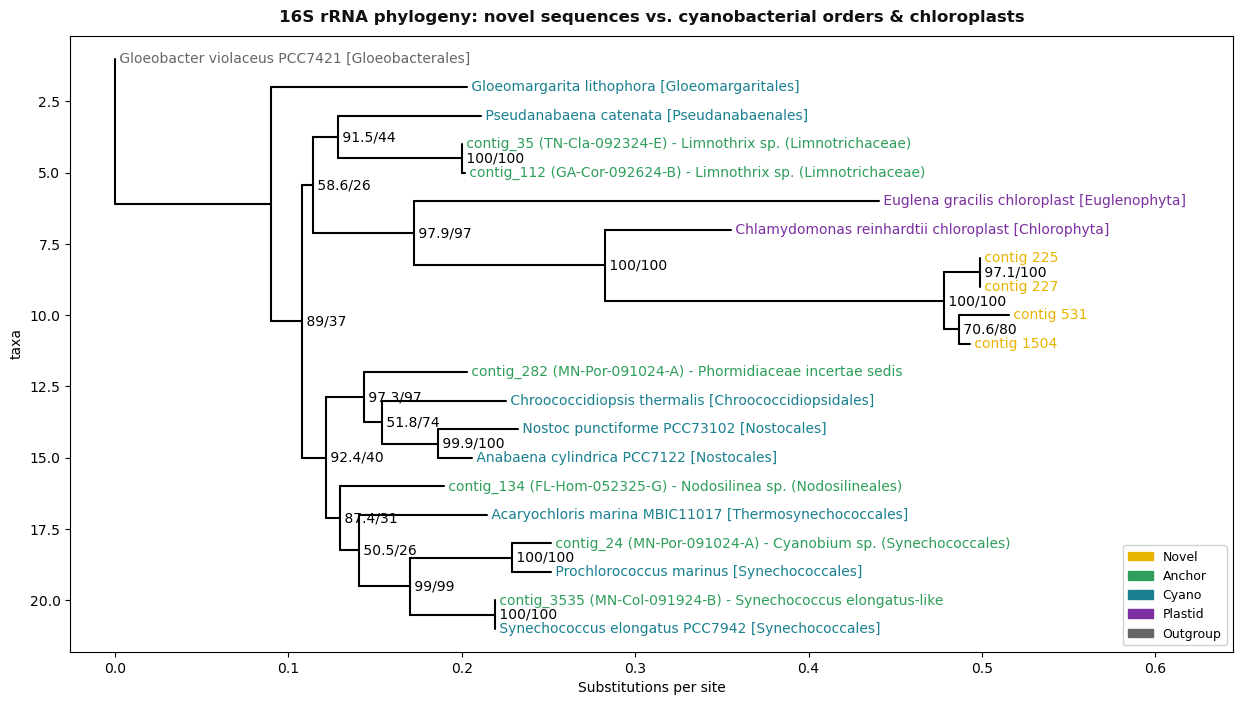

Saved -> figures/10_16S_phylo_tree.pdf/.png  (Bio.Phylo)

Color key:
  Novel        #E8B400
  Anchor       #2E9E5A
  Cyano        #1A8090
  Plastid      #7B2FA0
  Outgroup     #666666


In [8]:
# ── Step 5. Visualize the tree ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Phylo
import re, html

FIG_DIR = PROJECT / 'results' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

TREE_FILE = next(
    (f for f in [OUT_DIR / 'all_16S.treefile',
                 OUT_DIR / 'all_16S_fasttree.nwk'] if f.exists()), None)

if TREE_FILE is None:
    print('No tree file found — run Step 4 first'); raise SystemExit

OUTGROUP_ID = 'Cyano|Gloeobacter_violaceus_PCC7421|Gloeobacterales'
TITLE = '16S rRNA phylogeny: query contigs vs. cyanobacterial orders & chloroplasts'

# 'Query'  = the 6 contigs under test      'Sample' = our other sample-derived contigs
# 'Cyano'  = NCBI cyanobacterial references  'Plastid' = NCBI chloroplast references
CAT_COLORS = {
    'Query':    '#E8B400',
    'Sample':   '#2E9E5A',
    'Cyano':    '#1A8090',
    'Plastid':  '#7B2FA0',
    'Outgroup': '#666666',
}

# Internal nodes carry IQ-TREE's 'SH-aLRT/UFboot'. Only label well-supported ones —
# printing every node made the figure unreadable and gave weak splits equal visual weight.
MIN_UFBOOT = 70

def get_cat(tip_id):
    if tip_id.startswith('Query'):         return 'Query'
    if tip_id.startswith('Sample'):        return 'Sample'
    if tip_id.startswith('Plastid'):       return 'Plastid'
    if 'Gloeobacter_violaceus' in tip_id:  return 'Outgroup'
    return 'Cyano'

def short_label(tip_id):
    """tip_id is always a string (the newick tip name)."""
    lbl = label_map.get(tip_id)
    if lbl is None:
        parts = tip_id.split('|')
        lbl = parts[1].replace('_', ' ') if len(parts) > 1 else tip_id
    # Replace em-dash with hyphen (toyplot XML parser can't handle it)
    return lbl.replace('\u2014', '-').replace('\u2013', '-')

# ── toytree v3 ────────────────────────────────────────────────────────────────
try:
    import toytree, toyplot, toyplot.pdf, toyplot.png

    tree = toytree.tree(str(TREE_FILE))
    og_labels = [lb for lb in tree.get_tip_labels() if 'Gloeobacter_violaceus' in lb]
    if og_labels:
        tree = tree.root(*og_labels)

    tip_labels     = tree.get_tip_labels()
    tip_colors     = [CAT_COLORS.get(get_cat(n), '#888') for n in tip_labels]
    display_labels = [short_label(n) for n in tip_labels]

    h = max(600, tree.ntips * 20)
    w = 1050

    canvas = toyplot.Canvas(width=w, height=h,
                            style={"background-color": "white"})
    canvas.text(w / 2, 24, TITLE,
                style={"font-size": "13px", "font-weight": "bold",
                       "fill": "#111111", "text-anchor": "middle"})
    axes = canvas.cartesian(bounds=(160, w - 20, 44, h - 20))

    tree.draw(
        axes=axes,
        tip_labels=display_labels,
        tip_labels_colors=tip_colors,
        tip_labels_style={"font-size": "10px", "fill": "#111111"},
        edge_style={"stroke": "#333333", "stroke-width": 1.5},
        node_sizes=6,
        node_colors="#2E7D6E",
    )

    toyplot.pdf.render(canvas, str(FIG_DIR / '10_16S_phylo_tree.pdf'))
    toyplot.png.render(canvas, str(FIG_DIR / '10_16S_phylo_tree.png'), scale=2)
    print('Saved -> figures/10_16S_phylo_tree.pdf/.png  (toytree)')

except Exception as e:
    print(f'toytree path failed ({type(e).__name__}: {e}) -- using Bio.Phylo')

    tree = Phylo.read(str(TREE_FILE), 'newick')
    og_clade = next((c for c in tree.get_terminals()
                     if 'Gloeobacter_violaceus' in (c.name or '')), None)
    if og_clade:
        tree.root_with_outgroup(og_clade)
    tree.ladderize()

    # label_func receives a Clade object -- extract .name first
    def label_func(clade):
        name = clade.name or ''
        if not name:
            return ''
        if clade.is_terminal():
            return short_label(name)
        m = re.match(r'^([\d.]+)/([\d.]+)$', name)      # SH-aLRT/UFboot
        return name if (m and float(m.group(2)) >= MIN_UFBOOT) else ''

    # label_colors must be keyed by the display label string
    label_colors = {short_label(c.name): CAT_COLORS.get(get_cat(c.name or ''), '#888')
                    for c in tree.get_terminals()}

    n_tips = tree.count_terminals()
    fig, ax = plt.subplots(figsize=(15, max(8, n_tips * 0.32)), facecolor='white')
    ax.set_facecolor('white')

    Phylo.draw(tree, axes=ax, do_show=False,
               label_func=label_func,
               label_colors=label_colors)

    ax.set_title(TITLE, fontsize=12, fontweight='bold', color='#111111', pad=10)
    ax.set_xlabel('Substitutions per site')
    # Below the axes, never over the tree — at lower right it sat on top of the query clade.
    patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
    ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.045),
              ncol=len(CAT_COLORS), fontsize=9, frameon=False)
    ax.text(0.5, -0.085, f'Internal labels: SH-aLRT/UFboot, shown where UFboot >= {MIN_UFBOOT}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#666666')

    fig.savefig(FIG_DIR / '10_16S_phylo_tree.pdf', bbox_inches='tight', facecolor='white')
    fig.savefig(FIG_DIR / '10_16S_phylo_tree.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> figures/10_16S_phylo_tree.pdf/.png  (Bio.Phylo)')

print('\nColor key:')
for k, v in CAT_COLORS.items():
    print(f'  {k:<12} {v}')
